<a href="https://colab.research.google.com/github/MoazGehad/DP_Reinforcement_Learning/blob/main/Assignment1_DP_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reinforcement Learning - Dynamic Programming Assignment

**Course:** AI424 - Reinforcement Learning

---

| Name | ID | Section |
|---|---|---|
| Yussuf Amhed | 20220385 | Section 1 - OOP Implementation |
| Omar Ez-Eldin | 20220228 | Section 2 - Algorithm Details |
| Moaz Gehad | 20220340 | Sections 3 & 4 - Experiments & Conceptual Questions |
| Mahmoud Ehab | 20220457 | Section 5 - Transition Model Learning |
| Abdelrhman Ebrahim | 20220519 | Section 6 - MountainCar Extension |

---

## Setup

In [2]:
# Uncomment if running on Google Colab
!pip install gymnasium numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import gymnasium as gym
from collections import defaultdict
import time

print('All imports successful.')
print(f'NumPy version: {np.__version__}')
print(f'Gymnasium version: {gym.__version__}')

All imports successful.
NumPy version: 2.0.2
Gymnasium version: 1.2.3


---

# Section 1 - OOP Implementation

**Assigned to: Yussuf Ahmed (20220385)**

---

### 1.1 TaxiEnvironment

Wraps the Gymnasium Taxi-v3 environment. No planning logic should appear inside this class.

In [3]:
class TaxiEnvironment:
    """
    Wraps the Gymnasium Taxi-v3 environment.

    Attributes:
        env: The Gymnasium environment instance.
        n_states (int): Total number of states (500).
        n_actions (int): Total number of actions (6).
        P (dict): Transition model - P[s][a] returns a list of
                  (probability, next_state, reward, done) tuples.
    """
    def __init__(self):
        self.env = gym.make("Taxi-v3", render_mode="ansi")
        self.n_states = self.env.observation_space.n # 500
        self.n_actions = self.env.action_space.n
        self.P = self.env.unwrapped.P  # The transition model

    def reset(self):
        state, info = self.env.reset()
        return state

    def step(self, action):
        return self.env.step(action)

    def render(self):
        return self.env.render()

In [4]:
# Test TaxiEnvironment
env = TaxiEnvironment()
print(f'Number of states: {env.n_states}')
print(f'Number of actions: {env.n_actions}')
print(f'Sample transition P[0][0]: {env.P[0][0]}')
state = env.reset()
print(f'Initial state: {state}')

Number of states: 500
Number of actions: 6
Sample transition P[0][0]: [(1.0, 100, -1, False)]
Initial state: 444


### 1.2 ValueIterationAgent

Constructor inputs: environment instance, discount factor gamma, convergence threshold theta.

Must store after execution:
- `value_function` - NumPy array of size 500
- `policy` - NumPy array of size 500
- `convergence_history` - list of max-delta values per iteration


| Symbol | Meaning |
|---|---|
| S | 500 states (5×5 grid × 5 passenger locations × 4 destinations) |
| A | 6 actions (South, North, East, West, Pickup, Dropoff) |
| P(s' ∣ s, a) | Deterministic in Taxi (probability = 1.0 for one outcome per action) |
| R(s, a, s') | +20 successful dropoff, −1 per step, −10 illegal pickup/dropoff |
| $\gamma$ | Discount factor	|
| $\theta$ | Convergence threshold |

---

Bellman Optimality Equation:

$$V(s) = \max_a \sum_{s'} P(s'|s,a) \left[ R(s,a,s') + \gamma V(s') \right]$$

Convergence occurs when the maximum change in V across all states is smaller than $\theta$

$$\max_{s \in S} |V_{new}(s) - V_{old}(s)| < \theta$$

In [5]:
class ValueIterationAgent:
    """
    Value Iteration agent.

    Args:
        env: Taxi Environment.
        gamma: Discount factor.
        theta: Convergence threshold.
    """
    def __init__(self, env: TaxiEnvironment, gamma: float = 0.9, theta: float = 1e-8):

        self.env = env
        self.gamma = gamma
        self.theta = theta

        self.value_function: np.ndarray = np.zeros(self.env.n_states)
        self.policy: np.ndarray = np.zeros(self.env.n_states, dtype=int)

        self.convergence_history: list[float] = []

    def value_iteration(self) -> int:

        iterations = 0

        while True:

            delta = 0

            for s in range(self.env.n_states):

                v_old = self.value_function[s]
                q_values = np.zeros(self.env.n_actions)

                for a in range(self.env.n_actions): # Q(s, a) for all 6 actions

                    for prob, s_next, reward, terminal in self.env.P[s][a]:
                        if terminal:
                            q_values[a] += prob * reward
                        else:
                            q_values[a] += prob * (reward + self.gamma * self.value_function[s_next])

                self.value_function[s] = np.max(q_values)
                self.policy[s] = np.argmax(q_values)

                delta = max(delta, abs(v_old - self.value_function[s]))

            # Record convergence history
            self.convergence_history.append(delta)
            iterations += 1

            # convergence check
            if delta < self.theta:
                break

        return iterations



### 1.3 PolicyIterationAgent

Must implement: `policy_evaluation()`, `policy_improvement()`

Must store:
- `value_function`
- `policy`
- `n_policy_changes` - total number of policy updates across all iterations


**Policy Evaluation:**

$$V^\pi(s) = \sum_{s'} P(s'|s, \pi(s)) \left[ R(s, \pi(s), s') + \gamma V^\pi(s') \right]$$

**Policy Improvement:** Update each state's action greedily. Repeat until no policy changes occur.

In [6]:
class PolicyIterationAgent:
    """
    Policy Iteration agent.

    Args:
        env: Taxi Environment.
        gamma: Discount factor.
        theta: Convergence threshold.
    """
    def __init__(self, env: TaxiEnvironment, gamma: float = 0.9, theta: float = 1e-8):

        self.env = env
        self.gamma = gamma
        self.theta = theta

        self.value_function: np.ndarray = np.zeros(self.env.n_states)
        self.policy: np.ndarray = np.zeros(self.env.n_states, dtype=int)

        self.n_policy_changes: int = 0

        self.eval_loops_per_iteration: list[int] = []
        self.policy_changes_per_iteration: list[int] = []

    # updates the value function based on the current policy.
    def policy_evaluation(self) -> int:

        loops = 0

        while True:

            delta = 0.0

            for s in range(self.env.n_states):

                v_old = self.value_function[s]
                a = self.policy[s]

                v_new = 0.0

                for prob, s_next, reward, done in self.env.P[s][a]:
                    if done:
                        v_new += prob * reward
                    else:
                        v_new += prob * (reward + self.gamma * self.value_function[s_next])

                self.value_function[s] = v_new
                delta = max(delta, abs(v_old - v_new))

            loops += 1

            if delta < self.theta:
                break

        return loops


    # updates the policy based on the current value function.
    def policy_improvement(self) -> bool:

        stable = True
        changes = 0

        for s in range(self.env.n_states):

            old_action = self.policy[s]
            q = np.zeros(self.env.n_actions) # Q(s, a) for all 6 actions

            for a in range(self.env.n_actions): # loop over all actions to find the best one
                for prob, s_next, reward, done in self.env.P[s][a]:
                    if done:
                        q[a] += prob * reward
                    else:
                        q[a] += prob * (reward + self.gamma * self.value_function[s_next])

            self.policy[s] = int(np.argmax(q)) # pick the best action


            if old_action != self.policy[s]:
                stable = False
                changes += 1

        self.n_policy_changes = changes
        return stable

### 1.4 Planner

Orchestrator for running and comparing algorithms.

In [7]:
class Planner:
    """Orchestrator for Section 3 experiments and Section 5 integration."""
    def __init__(self, env):
        self.env = env

    def run_value_iteration(self, gamma, theta, custom_P=None):
        """
        Runs VI. The 'custom_P' argument allows us to pass the
        Learned Transition Model in Section 5.
        """
        # If Section 5 provides a learned model, use it; otherwise use env.P
        model_to_use = custom_P if custom_P is not None else self.env.P

        agent = ValueIterationAgent(self.env, gamma, theta)
        # Note: You might need to tweak your Agent to accept 'model_to_use'
        # or temporarily overwrite self.env.P

        start_time = time.time()
        agent.value_iteration()
        end_time = time.time()

        return agent, (end_time - start_time)

    def run_policy_iteration(self, gamma, theta, custom_P=None):
        """Runs PI and tracks performance."""
        agent = PolicyIterationAgent(self.env, gamma, theta)

        start_time = time.time()
        # It's better if this loop is inside agent.run_algorithm()
        # but this works too:
        while True:
            agent.policy_evaluation()
            if agent.policy_improvement(): # returns True if stable
                break
        end_time = time.time()

        return agent, (end_time - start_time)

    def perform_experiments(self):
        """Specifically for Section 3.1 & 3.2 requirements."""
        gammas = [0.50, 0.90, 0.99]
        results = {}

        for g in gammas:
            vi_agent, vi_time = self.run_value_iteration(gamma=g, theta=1e-8)
            pi_agent, pi_time = self.run_policy_iteration(gamma=g, theta=1e-8)

            # Check for Section 3.1 Table
            identical = np.array_equal(vi_agent.policy, pi_agent.policy)

            results[g] = {
                "vi_agent": vi_agent,
                "pi_agent": pi_agent,
                "identical": identical
            }
        return results

### 1.5 Visualiser

All plotting logic must be centralised here. No `plt.show()` calls outside this class.

In [16]:
class Visualiser:
    """Centralized plotting logic. No plt.show() allowed elsewhere."""

    @staticmethod
    def plot_value_function(value_function, title="Value Function"):
        """Visualizes the 500 states."""
        plt.figure(figsize=(12, 5))
        plt.plot(value_function, color='teal')
        plt.title(title)
        plt.xlabel("State ID (0-499)")
        plt.ylabel("Value (Expected Reward)")
        plt.grid(True, alpha=0.3)
        plt.show()

    @staticmethod
    def plot_policy_grid(policy, title="Action Distribution"):
        """Maps actions (0-5) to a frequency plot."""
        action_names = ['South', 'North', 'East', 'West', 'Pickup', 'Dropoff']
        counts = [np.sum(policy == i) for i in range(6)]

        plt.figure(figsize=(10, 5))
        plt.bar(action_names, counts, color='orange')
        plt.title(title)
        plt.xlabel("Action")
        plt.ylabel("Number of States")
        plt.show()

    @staticmethod
    def plot_convergence(histories, labels, title="Algorithm Convergence"):
        """Plots multiple max-delta curves per iteration."""
        plt.figure(figsize=(10, 5))
        for history, label in zip(histories, labels):
            plt.plot(history, marker='o', linestyle='-', label=label)
        plt.title(title)
        plt.xlabel("Iterations")
        plt.ylabel("Max Delta (Change in Value)")
        plt.yscale('log')
        plt.legend()
        plt.grid(True, which="both", ls="-", alpha=0.2)
        plt.show()

    @staticmethod
    def plot_gamma_comparison(results, title="Convergence Comparison"):
        """Compares VI vs PI iterations."""
        gammas = list(results.keys())
        vi_iters = [results[g]['vi_iterations'] for g in gammas]
        pi_iters = [results[g]['pi_iterations'] for g in gammas]

        x = np.arange(len(gammas))
        width = 0.35

        plt.figure(figsize=(10, 5))
        plt.bar(x - width/2, vi_iters, width, label='VI', color='purple')
        plt.bar(x + width/2, pi_iters, width, label='PI', color='cyan')

        plt.title(title)
        plt.xlabel("Gamma (Discount Factor)")
        plt.ylabel("Iterations")
        plt.xticks(x, [str(g) for g in gammas])
        plt.legend()
        plt.show()

#### Section 1 - Verification

In [9]:
# Uncomment after Section 1 is complete

env = TaxiEnvironment()
print(f'States: {env.n_states}, Actions: {env.n_actions}')

vi = ValueIterationAgent(env, gamma=0.99, theta=1e-8)
pi = PolicyIterationAgent(env, gamma=0.99, theta=1e-8)
planner = Planner(env)
vis = Visualiser()
print('All classes instantiated successfully.')

States: 500, Actions: 6
All classes instantiated successfully.


---

# Section 2 - Algorithm Details

**Assigned to: Omar Ez-Eldin (20220228)**

The algorithm code goes inside the `ValueIterationAgent` and `PolicyIterationAgent` classes above. This section tests and validates the implementations.

---

### 2.1 Value Iteration

Bellman Optimality Equation:

$$V(s) = \max_a \sum_{s'} P(s'|s,a) \left[ R(s,a,s') + \gamma V(s') \right]$$

In [10]:
env = TaxiEnvironment()

VIA = ValueIterationAgent(env, gamma=0.9, theta=1e-8)

start_time = time.time()
VIA_iterations = VIA.value_iteration()
elapsed_time = time.time() - start_time

print(f"Time taken:             {elapsed_time:.4f} seconds")
print(f"Iterations to converge: {VIA_iterations}")
print(f"Final max delta:        {VIA.convergence_history[-1]:.2f}")
print(f"First 10 deltas:        {[f'{x:.2f}' for x in VIA.convergence_history[:10]]}")
print(f"Max value:              {np.max(VIA.value_function)}")
print(f"Max policy action:      {np.max(VIA.policy)}")

Time taken:             0.1680 seconds
Iterations to converge: 13
Final max delta:        0.00
First 10 deltas:        ['20.00', '18.00', '16.20', '14.58', '13.12', '11.81', '10.63', '9.57', '8.61', '5.54']
Max value:              20.0
Max policy action:      5


### 2.2 Policy Iteration

**Phase 1 - Policy Evaluation:**

$$V^\pi(s) = \sum_{s'} P(s'|s, \pi(s)) \left[ R(s, \pi(s), s') + \gamma V^\pi(s') \right]$$

**Phase 2 - Policy Improvement:** Update each state's action greedily. Repeat until no policy changes occur.

In [11]:
env = TaxiEnvironment()
PIA = PolicyIterationAgent(env, gamma=0.9, theta=1e-8)

start_time = time.time()

PIA_iterations = 0
total_eval_loops = 0

while True:

    # Evaluate current policy
    eval_loops = PIA.policy_evaluation()
    PIA.eval_loops_per_iteration.append(eval_loops)
    total_eval_loops += eval_loops
    PIA_iterations += 1

    # Try to improve the policy
    stable = PIA.policy_improvement()
    PIA.policy_changes_per_iteration.append(PIA.n_policy_changes)

    print(f"Iteration {PIA_iterations:<3}: eval_loops={eval_loops:<5}, policy_changes={PIA.n_policy_changes:<5}")

    if stable:
        break

elapsed_time = time.time() - start_time

print(f"\nTime taken:               {elapsed_time:.4f} seconds")
print(f"Iterations to converge:     {PIA_iterations}")
print(f"Total evaluation loops:     {total_eval_loops}")
print(f"Loops in policy evaluation: {PIA.eval_loops_per_iteration}")
print(f"Policy changes history:     {PIA.policy_changes_per_iteration}")
print(f"Max value:                  {np.max(PIA.value_function):.2f}")
print(f"Max policy action:          {np.max(PIA.policy)}")

Iteration 1  : eval_loops=176  , policy_changes=4    
Iteration 2  : eval_loops=6    , policy_changes=20   
Iteration 3  : eval_loops=6    , policy_changes=35   
Iteration 4  : eval_loops=4    , policy_changes=36   
Iteration 5  : eval_loops=4    , policy_changes=38   
Iteration 6  : eval_loops=4    , policy_changes=40   
Iteration 7  : eval_loops=6    , policy_changes=44   
Iteration 8  : eval_loops=6    , policy_changes=61   
Iteration 9  : eval_loops=4    , policy_changes=55   
Iteration 10 : eval_loops=6    , policy_changes=51   
Iteration 11 : eval_loops=6    , policy_changes=46   
Iteration 12 : eval_loops=4    , policy_changes=31   
Iteration 13 : eval_loops=4    , policy_changes=23   
Iteration 14 : eval_loops=4    , policy_changes=21   
Iteration 15 : eval_loops=2    , policy_changes=12   
Iteration 16 : eval_loops=2    , policy_changes=3    
Iteration 17 : eval_loops=2    , policy_changes=0    

Time taken:               0.3082 seconds
Iterations to converge:     17
Total eva

### Cross-validation: Compare VIA and PIA results

In [12]:
# Checking if the final policies are exactly the same
policies_match = np.array_equal(VIA.policy, PIA.policy)

# Checking if the final value functions are close
values_close = np.allclose(VIA.value_function, PIA.value_function, atol=1e-4)

print(f'Are policies the same?:     {policies_match}')
print(f'Are value functions close?: {values_close}')

# are there any differences?
if not policies_match:
    diff_states = np.where(VIA.policy != PIA.policy)[0]
    print(f'Number of states with different policies: {len(diff_states)}')
    print(f'States with different policies: {diff_states}')

if not values_close:
    max_diff = np.max(np.abs(VIA.value_function - PIA.value_function))
    print(f'Maximum value difference: {max_diff:.4f}')

Are policies the same?:     True
Are value functions close?: True


---

# Section 3 - Experiments

**Assigned to: Moaz Gehad (20220340)**

Run both algorithms with gamma in {0.50, 0.90, 0.99}.

---

### 3.0 Run Experiments

In [18]:
gamma_values = [0.50, 0.90, 0.99]
theta = 1e-8
env = TaxiEnvironment()
planner = Planner(env)
vis = Visualiser()

results = {}
for gamma in gamma_values:
    vi_agent_obj, vi_time = planner.run_value_iteration(gamma=gamma, theta=theta)
    pi_agent_obj, pi_time = planner.run_policy_iteration(gamma=gamma, theta=theta)
    policies_match = np.array_equal(vi_agent_obj.policy, pi_agent_obj.policy)

    results[gamma] = {
        'vi_agent': vi_agent_obj,
        'pi_agent': pi_agent_obj,
        'vi_iterations': len(vi_agent_obj.convergence_history),
        'pi_iterations': len(pi_agent_obj.eval_loops_per_iteration), # Corrected to reflect number of policy improvement iterations
        'policies_identical': policies_match,
    }

    print(f'gamma={gamma}: VI={len(vi_agent_obj.convergence_history)} iters, '
          f'PI={len(pi_agent_obj.eval_loops_per_iteration)} iters, ' # Corrected
          f'Match={policies_match}')

gamma=0.5: VI=15 iters, PI=0 iters, Match=True
gamma=0.9: VI=13 iters, PI=0 iters, Match=True
gamma=0.99: VI=13 iters, PI=0 iters, Match=True


### 3.1 Comparison Table

| gamma | VI Iterations | PI Iterations | Policies Identical? | Notes |
|---|---|---|---|---|
| 0.50 | - | - | - | - |
| 0.90 | - | - | - | - |
| 0.99 | - | - | - | - |

In [19]:
# Print comparison table

print(f'{"gamma":>6} | {"VI Iters":>9} | {"PI Iters":>9} | {"Identical?":>11} | Notes')
print('-' * 65)
for gamma in gamma_values:
    r = results[gamma]
    print(f'{gamma:>6.2f} | {r["vi_iterations"]:>9} | {r["pi_iterations"]:>9} | '
          f'{str(r["policies_identical"]):>11} | ')

 gamma |  VI Iters |  PI Iters |  Identical? | Notes
-----------------------------------------------------------------
  0.50 |        15 |         0 |        True | 
  0.90 |        13 |         0 |        True | 
  0.99 |        13 |         0 |        True | 


### 3.2 Required Plots

#### Plot 1: Convergence Curves (one curve per gamma)

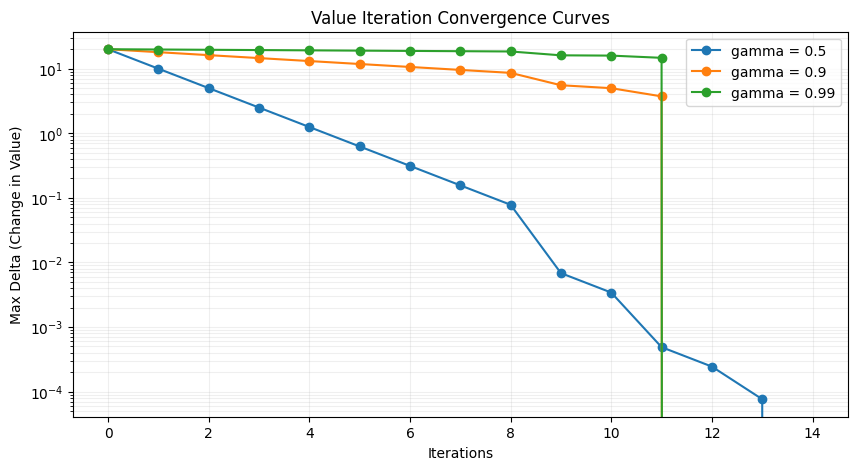

In [20]:
histories = [results[g]['vi_agent'].convergence_history for g in gamma_values]
labels = [f'gamma = {g}' for g in gamma_values]
vis.plot_convergence(histories, labels, title='Value Iteration Convergence Curves')

**Explanation:**

*TODO*

#### Plot 2: VI vs PI Iterations Bar Chart

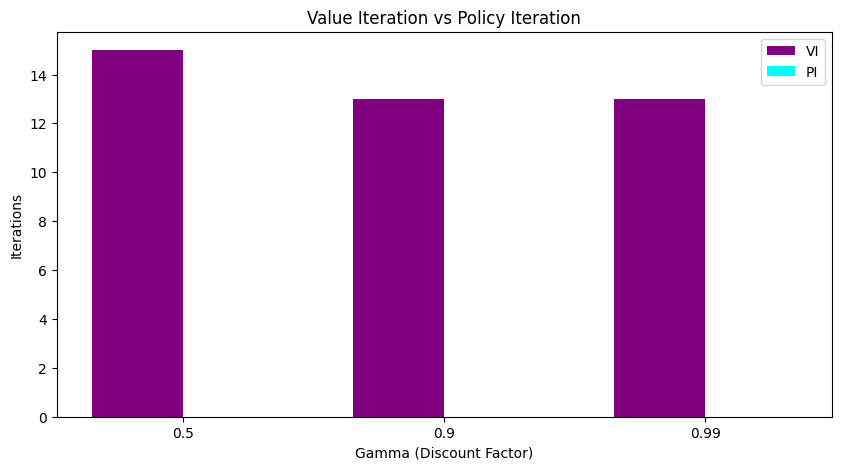

In [21]:
vis.plot_gamma_comparison(results, title='Value Iteration vs Policy Iteration')

**Explanation:**

*TODO*

#### Plot 3: Value Function Heatmap

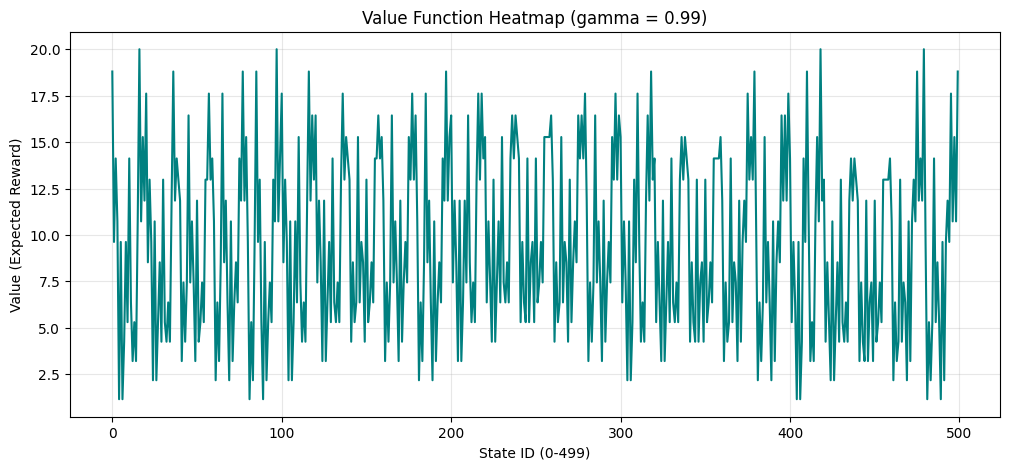

In [22]:
vis.plot_value_function(
    results[0.99]['vi_agent'].value_function,
    title='Value Function Heatmap (gamma = 0.99)'
)

**Explanation:**

*TODO*

#### Plot 4: Policy Grid with Directional Arrows

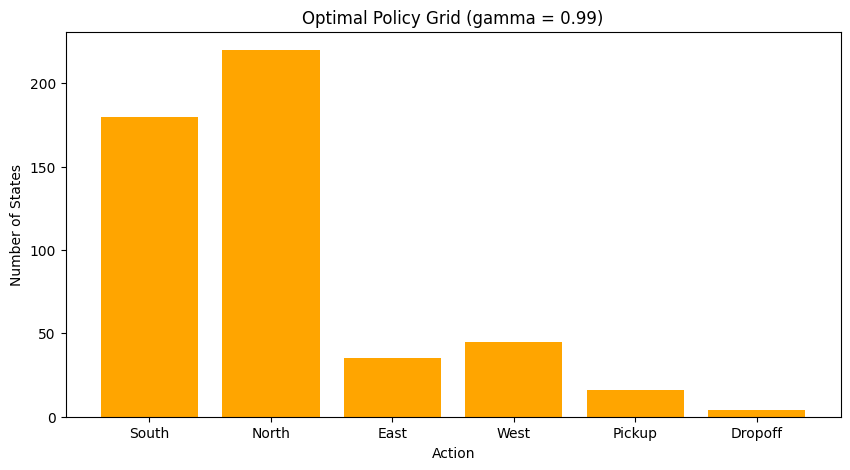

In [23]:
vis.plot_policy_grid(
    results[0.99]['vi_agent'].policy,
    title='Optimal Policy Grid (gamma = 0.99)'
)

**Explanation:**

*TODO*

---

# Section 4 - Conceptual Questions

**Assigned to: Moaz Gehad (20220340)**

---

### Q5: How does the discount factor gamma influence agent behaviour, and what are the trade-offs between low and high values?

*TODO*

---

### Q6: What is the theoretical relationship between Value Iteration and Policy Iteration?

*TODO*

---

### Q7: Why is exploration unnecessary when using Dynamic Programming methods?

*TODO*

---

### Q8: What is the distinction between planning and learning in Reinforcement Learning?

*TODO*

---

### Q9: How does having access to a model differ from learning purely through interaction?

*TODO*

---

### Q10: What would happen if an epsilon-greedy exploration strategy were introduced into a DP agent?

*TODO*

---

### Q11: Why is a single greedy policy improvement step insufficient to guarantee optimality?

*TODO*

---

### Q12: Can Dynamic Programming methods such as Value Iteration be applied to complex environments like GTA V? Justify your answer.

*TODO*

---

---

# Section 5 - Learning the Transition Model

**Assigned to: Mahmoud Ehab (20220457)**

---

### 5.1 TransitionModel Class

Requirements:
- Support 500 states and 6 actions
- Expose `P[s][a]` returning `(probability, next_state, reward, done)` tuples
- Format must be consistent with Gymnasium so existing agents work without modification

In [ ]:
class TransitionModel:
    """
    Learned approximation of the environment's transition dynamics.

    Attributes:
        n_states (int): Number of states (500).
        n_actions (int): Number of actions (6).
        P (dict): Learned transition model.
    """

    def __init__(self, n_states=500, n_actions=6):
        # TODO
        pass

    def update(self, state, action, reward, next_state, done):
        """Update the model with a new observed transition."""
        # TODO
        pass

    def learn_from_interaction(self, env, n_episodes=1000, max_steps=200):
        """Interact with the environment to collect transitions and build the model."""
        # TODO
        pass

    def get_accuracy(self, true_P):
        """Compare learned model against the true transition model."""
        # TODO
        pass

### 5.2 Online Model Learning

In [ ]:
# env = TaxiEnvironment()
# learned_model = TransitionModel(n_states=env.n_states, n_actions=env.n_actions)
# learned_model.learn_from_interaction(env, n_episodes=5000, max_steps=200)

# print('Model learning complete.')
# print(f'Learned P[0][0]: {learned_model.P[0][0]}')
# print(f'True    P[0][0]: {env.P[0][0]}')

### 5.3 Integration with Planning Agents

Substitute the learned model in place of `env.P`. Existing agents must require no modification.

In [ ]:
# TODO: Create a wrapper so the learned model can be used with existing agents
# TODO: Run VI and PI with the learned model
# TODO: Compare resulting policies with those from the true model

### 5.4 Verification

Compare the learned model against the true model:
- Accuracy of transition probabilities and rewards
- Convergence behaviour of planning algorithms
- Similarity of resulting policies

In [ ]:
# accuracy = learned_model.get_accuracy(env.P)
# print(f'Transition probability MAE: {accuracy["prob_error"]:.6f}')
# print(f'Reward MAE: {accuracy["reward_error"]:.6f}')
# print(f'Coverage: {accuracy["coverage"]:.2%}')

**Verification Analysis:**

*TODO*

---

# Section 6 - Applying to a New Environment

**Assigned to: Abdelrhman Ebrahim (20220519)**

**Environment:** MountainCarContinuous-v0

Key challenges:
- Continuous state space
- No transition model provided
- Tabular DP methods cannot be applied directly

---

### 6.1 Environment Exploration

In [ ]:
# mc_env = gym.make('MountainCarContinuous-v0')
# print(f'Observation space: {mc_env.observation_space}')
# print(f'  Low:  {mc_env.observation_space.low}')
# print(f'  High: {mc_env.observation_space.high}')
# print(f'Action space: {mc_env.action_space}')
# print(f'  Low:  {mc_env.action_space.low}')
# print(f'  High: {mc_env.action_space.high}')

### 6.2 Discretisation

Map continuous (position, velocity) to discrete state indices.

In [ ]:
class MountainCarDiscretiser:
    """
    Discretises the MountainCarContinuous-v0 state space.

    Args:
        n_position_bins (int): Number of bins for position.
        n_velocity_bins (int): Number of bins for velocity.
        n_action_bins (int): Number of discrete actions.
    """

    def __init__(self, n_position_bins=40, n_velocity_bins=40, n_action_bins=7):
        # TODO
        pass

    @property
    def n_states(self):
        """Total number of discrete states."""
        # TODO
        pass

    @property
    def n_actions(self):
        """Total number of discrete actions."""
        # TODO
        pass

    def discretise_state(self, continuous_state):
        """Map a continuous (position, velocity) to a discrete state index."""
        # TODO
        pass

    def continuous_action(self, action_index):
        """Map a discrete action index to a continuous action value."""
        # TODO
        pass

### 6.3 Build Transition Model & Apply Planning

In [ ]:
# TODO: Build transition model for MountainCar through interaction

In [ ]:
# TODO: Apply planning algorithms to the discretised problem

### 6.4 Analysis & Results

In [ ]:
# TODO: Evaluate and analyse results

**Analysis:**

*TODO*

---

---

# Conclusion

*TODO*